In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer

In [3]:
# Load the dataset
df = pd.read_csv('../data/raw_analyst_ratings.csv')

In [4]:
# --- 1. Descriptive Statistics: Headline Length ---
df['headline_length'] = df['headline'].astype(str).apply(len)

In [5]:
# Show basic stats
print("Headline Length Stats:\n", df['headline_length'].describe())

Headline Length Stats:
 count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64


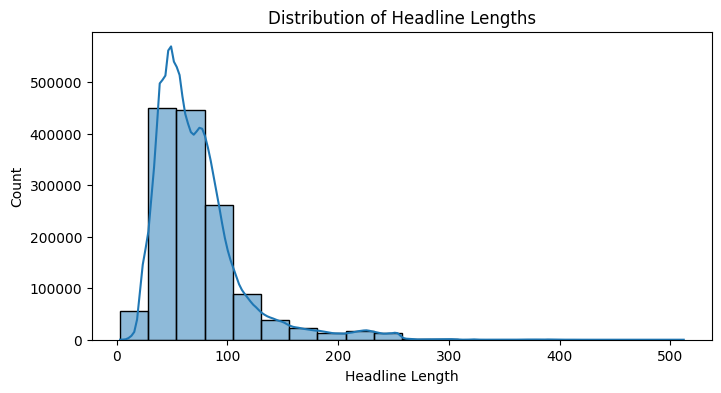

In [6]:
# Distribution plot
plt.figure(figsize=(8, 4))
sns.histplot(df['headline_length'], kde=True, bins=20)
plt.title('Distribution of Headline Lengths')
plt.xlabel('Headline Length')
plt.ylabel('Count')
plt.show()

In [7]:
# --- 2. Articles per Publisher ---
publisher_counts = df['publisher'].value_counts()
print("\nArticles per Publisher:\n", publisher_counts)


Articles per Publisher:
 publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
                      ...  
MoneyGeek                 1
muathe                    1
Robert Morris             1
LeftCoastHedgie           1
Jeremie Capron            1
Name: count, Length: 1034, dtype: int64


In [8]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')  # coerce will handle badly formatted dates as NaT

df['date'] = df['date'].dt.tz_convert('UTC') if df['date'].dt.tz is not None else df['date']

# Extract just the date (drop time)
df['pub_date'] = df['date'].dt.date

# Count articles per day
daily_counts = df.groupby('pub_date').size()

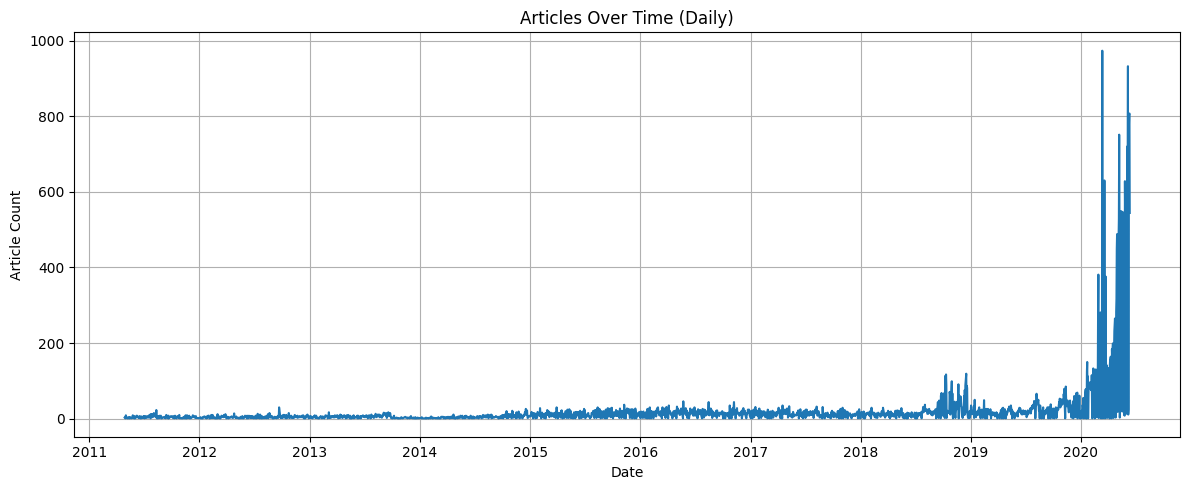

In [9]:
plt.figure(figsize=(12, 5))
daily_counts.plot()
plt.title('Articles Over Time (Daily)')
plt.xlabel('Date')
plt.ylabel('Article Count')
plt.grid(True)
plt.tight_layout()
plt.show()


Articles by Day of Week:
 weekday
Friday        9407
Monday       10297
Saturday       273
Sunday         388
Thursday     12712
Tuesday      11037
Wednesday    11873
Name: count, dtype: int64


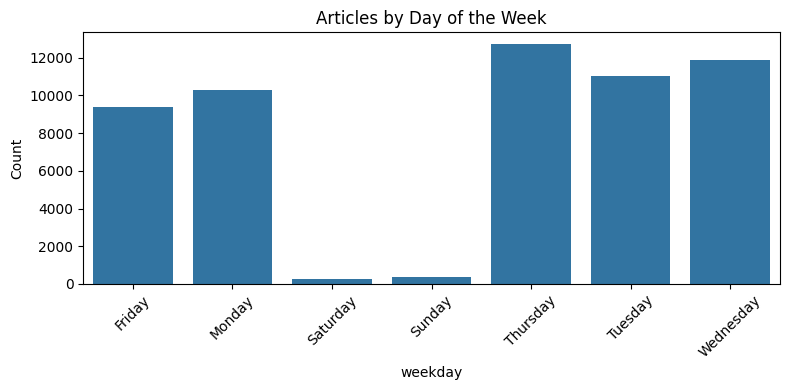

In [10]:
df['weekday'] = df['date'].dt.day_name()
weekday_counts = df['weekday'].value_counts().sort_index()

print("\nArticles by Day of Week:\n", weekday_counts)

# Bar plot for weekday distribution
plt.figure(figsize=(8, 4))
sns.barplot(x=weekday_counts.index, y=weekday_counts.values)
plt.title('Articles by Day of the Week')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
headlines = df['headline'].astype(str).dropna()

In [14]:
# TF-IDF on unigrams and bigrams
vectorizer = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1, 2),       # unigrams + bigrams
    min_df=10,                # appears in at least 10 headlines
    max_df=0.8,               # appears in no more than 80% of headlines
    max_features=1000         # only the top 1000 phrases
)

X = vectorizer.fit_transform(headlines)
feature_names = vectorizer.get_feature_names_out()

# Compute average TF-IDF scores
avg_scores = X.mean(axis=0).A1
keywords_scores = list(zip(feature_names, avg_scores))
keywords_scores.sort(key=lambda x: x[1], reverse=True)


C:\Users\pc\AppData\Local\Temp\ipykernel_2080\486137321.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_keywords_df, y='keyword_or_phrase', x='avg_tfidf', palette='viridis')


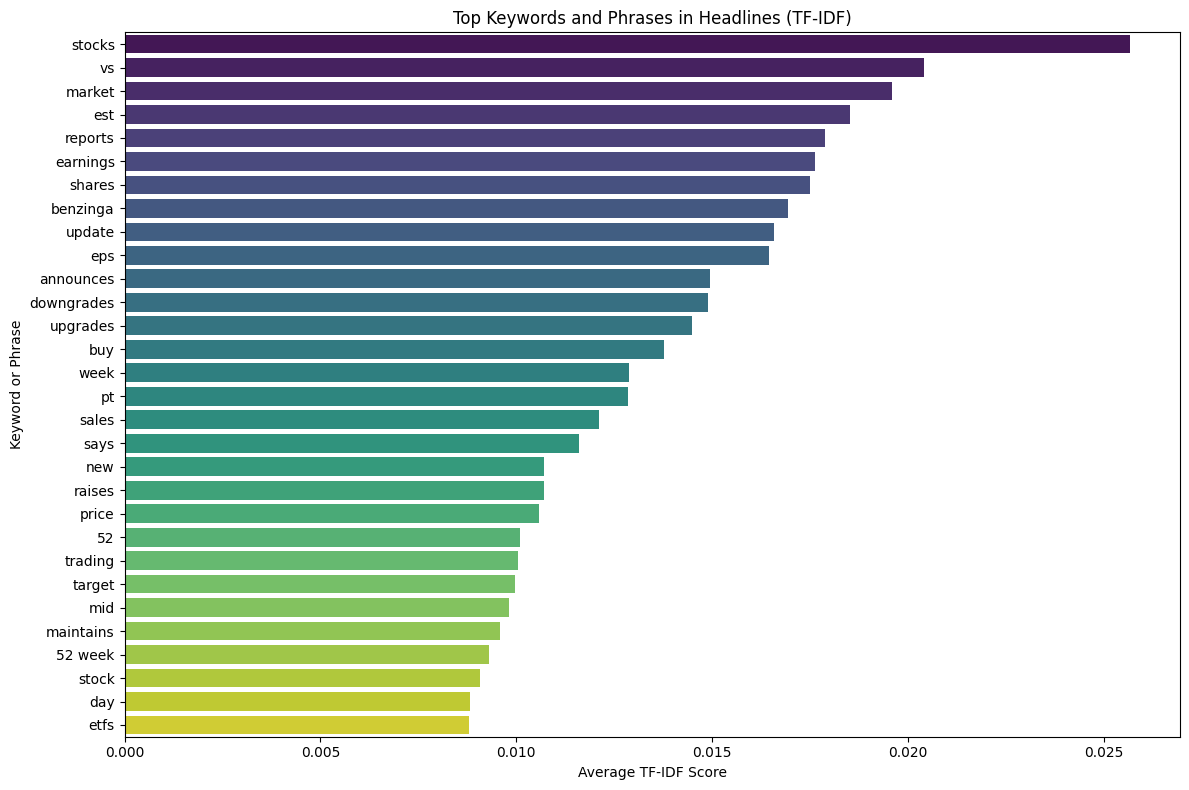

In [15]:
# Top 30 keywords
top_keywords_df = pd.DataFrame(keywords_scores, columns=['keyword_or_phrase', 'avg_tfidf']).head(30)

# Plot
plt.figure(figsize=(12, 8))
sns.barplot(data=top_keywords_df, y='keyword_or_phrase', x='avg_tfidf', palette='viridis')
plt.title('Top Keywords and Phrases in Headlines (TF-IDF)')
plt.xlabel('Average TF-IDF Score')
plt.ylabel('Keyword or Phrase')
plt.tight_layout()
plt.show()

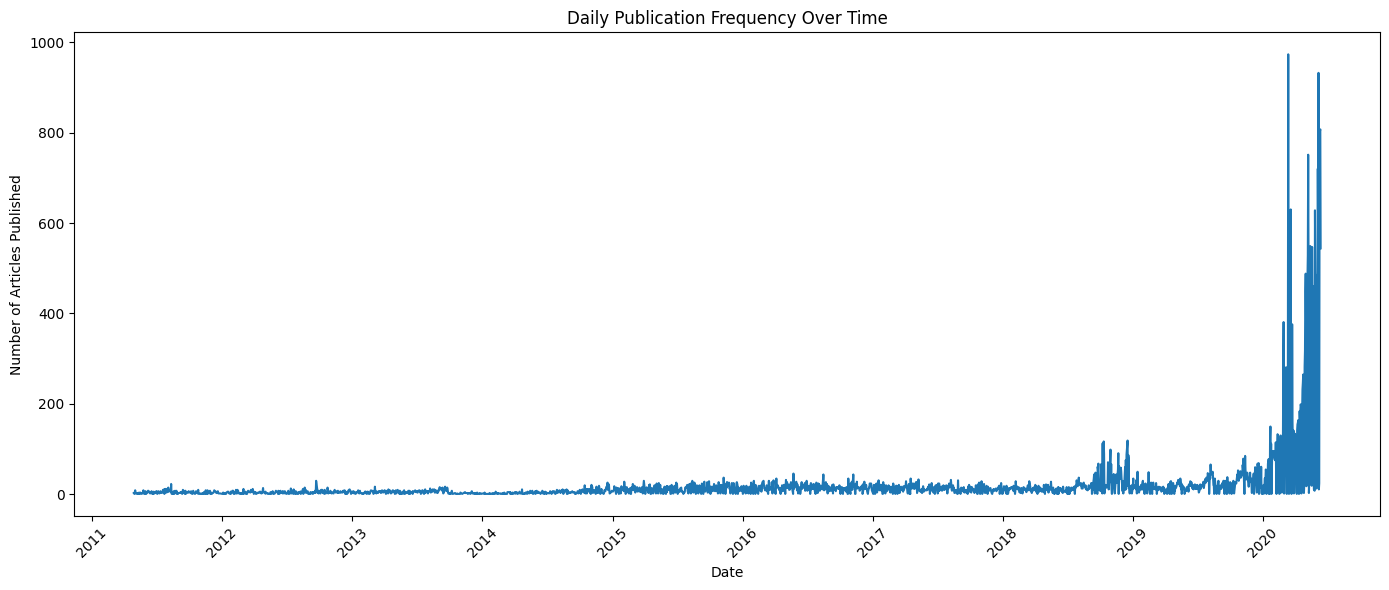

In [17]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')  # parse dates, invalid ones become NaT
df = df.dropna(subset=['date'])  # drop rows where date couldn't be parsed

df['date_only'] = df['date'].dt.date
daily_counts = df.groupby('date_only').size().reset_index(name='num_articles')

plt.figure(figsize=(14,6))
sns.lineplot(data=daily_counts, x='date_only', y='num_articles')
plt.title('Daily Publication Frequency Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Articles Published')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

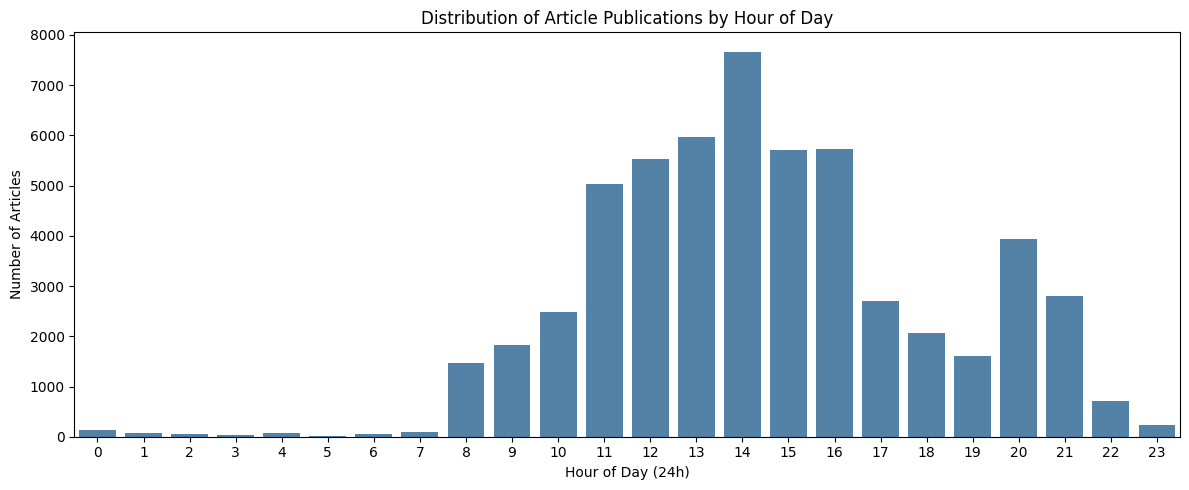

In [18]:
df['hour'] = df['date'].dt.hour

plt.figure(figsize=(12,5))
sns.countplot(data=df, x='hour', color='steelblue')
plt.title('Distribution of Article Publications by Hour of Day')
plt.xlabel('Hour of Day (24h)')
plt.ylabel('Number of Articles')
plt.tight_layout()
plt.show()